# Pertemuan 7 - Pengantar Machine Learning: Regresi Linear

Nama: Difa Asmana  
NIM: 240401010008  
Mata Kuliah: Pengantar Data Science  

Notebook ini berisi hands-on prediksi gaji menggunakan Regresi Linear. Tahapan yang dilakukan meliputi generate dataset sintetis, eksplorasi data, preprocessing, train-test split, feature scaling, pelatihan model, evaluasi model, dan visualisasi hasil prediksi.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Generate dan Eksplorasi Dataset

Dataset yang digunakan adalah dataset sintetis prediksi gaji. Fitur yang digunakan adalah pengalaman kerja, tingkat pendidikan, dan kota kerja. Target yang diprediksi adalah gaji dalam satuan juta rupiah.

In [26]:
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print('Shape:', df.shape)
display(df.head())

Shape: (300, 4)


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


In [27]:
print('Informasi Dataset:')
df.info()

print('\nStatistik Deskriptif:')
display(df.describe().round(2))

print('\nJumlah data per kota:')
print(df['kota'].value_counts())

print('\nJumlah data per tingkat pendidikan:')
print(df['edu'].value_counts())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pengalaman  300 non-null    float64
 1   edu         300 non-null    int64  
 2   kota        300 non-null    object 
 3   gaji        300 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB

Statistik Deskriptif:


,pengalaman,edu,gaji
count,300.00,300.00,300.00
mean,9.90,0.89,27.40
std,5.89,0.83,13.41
min,0.10,0.00,1.67
25%,4.78,0.00,16.24
50%,10.23,1.00,27.97
75%,15.14,2.00,38.89
max,19.80,2.00,54.22



Jumlah data per kota:
kota
Surabaya    106
Jakarta      97
Bandung      97
Name: count, dtype: int64

Jumlah data per tingkat pendidikan:
edu
0    121
1     92
2     87
Name: count, dtype: int64


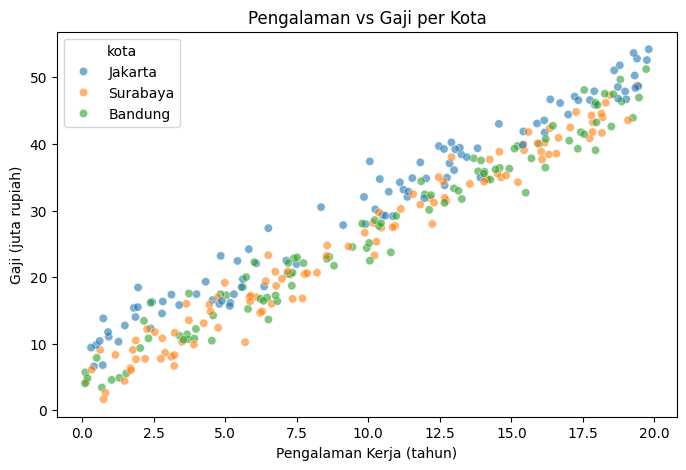

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    alpha=0.6
)

plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman Kerja (tahun)')
plt.ylabel('Gaji (juta rupiah)')
plt.show()

## 2. Preprocessing Data

Pada tahap ini, kolom kategorikal `kota` diubah menjadi numerik menggunakan One-Hot Encoding. Setelah itu, fitur dan target dipisahkan, lalu data dibagi menjadi data latih dan data uji.

In [29]:
df_encoded = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print('Kolom setelah encoding:')
print(df_encoded.columns.tolist())

display(df_encoded.head())

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [30]:
X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

print('Fitur X:')
display(X.head())

print('\nTarget y:')
display(y.head())

Fitur X:


,pengalaman,edu,kota_Jakarta,kota_Surabaya
0,7.490802,0,1,0
1,19.014286,1,1,0
2,14.639879,2,0,1
3,11.973170,2,0,0
4,3.120373,2,1,0



Target y:


,gaji
0,21.953247
1,46.721665
2,34.952649
3,32.437143
4,17.384265


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')

Train: 240 baris
Test : 60 baris


In [32]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Feature scaling selesai.')
print('Shape X_train_s:', X_train_s.shape)
print('Shape X_test_s :', X_test_s.shape)

Feature scaling selesai.
Shape X_train_s: (240, 4)
Shape X_test_s : (60, 4)


## 3. Melatih Model Regresi Linear

Model yang digunakan adalah LinearRegression dari scikit-learn. Model akan belajar hubungan antara fitur `pengalaman`, `edu`, dan `kota` terhadap target `gaji`.

In [33]:
model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')

β₀ (intercept): 27.514


In [34]:
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

display(coef_df)

,Fitur,Koefisien
0,pengalaman,13.042
2,kota_Jakarta,1.837
1,edu,1.188
3,kota_Surabaya,-0.292


## 4. Evaluasi Model

Evaluasi model dilakukan menggunakan MAE, RMSE, dan R-Squared. MAE dan RMSE menunjukkan rata-rata kesalahan prediksi dalam satuan juta rupiah, sedangkan R-Squared menunjukkan seberapa besar variasi data yang dapat dijelaskan oleh model.

In [35]:
y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


## 5. Interpretasi Hasil Evaluasi

MAE menunjukkan rata-rata selisih absolut antara gaji aktual dan gaji prediksi. RMSE menunjukkan kesalahan prediksi dengan penalti lebih besar terhadap error yang besar. R-Squared menunjukkan seberapa baik model menjelaskan variasi gaji berdasarkan fitur yang digunakan.

Jika nilai R-Squared tinggi, maka model cukup baik dalam menjelaskan hubungan antara pengalaman, pendidikan, kota, dan gaji. Jika selisih RMSE dan MAE tidak terlalu besar, maka tidak terdapat indikasi outlier error yang terlalu ekstrem.

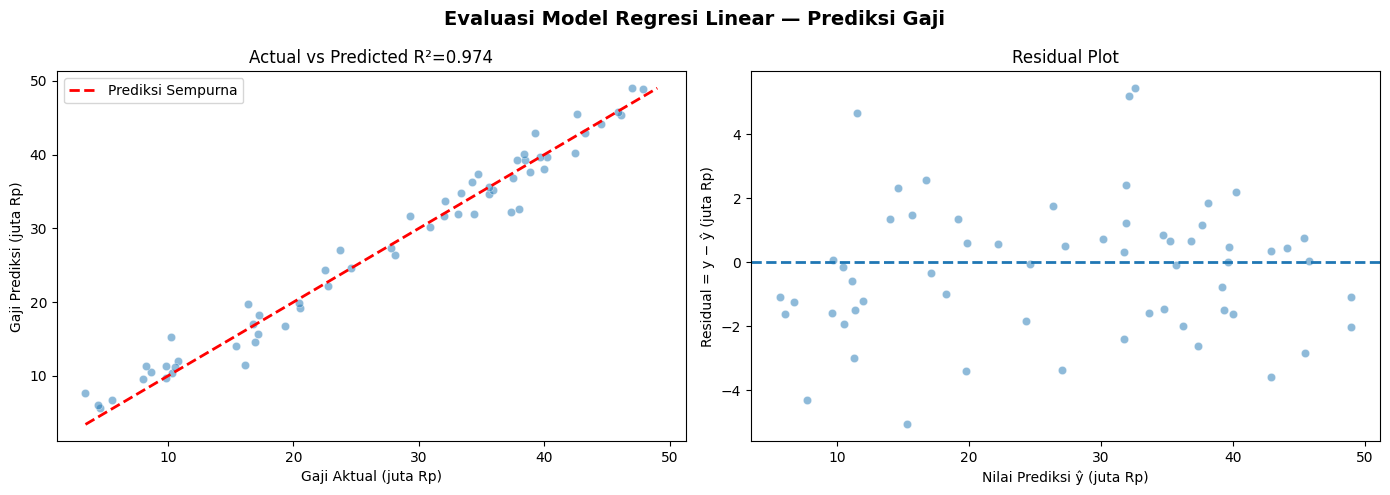

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--',
    lw=2,
    label='Prediksi Sempurna'
)

axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(0, linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Kesimpulan

Pada hands-on ini, model Regresi Linear berhasil dibuat untuk memprediksi gaji berdasarkan pengalaman kerja, pendidikan, dan kota kerja. Proses yang dilakukan meliputi generate dataset sintetis, eksplorasi data, encoding data kategorikal, train-test split, feature scaling, pelatihan model, evaluasi menggunakan MAE, RMSE, dan R-Squared, serta visualisasi Actual vs Predicted dan Residual Plot.

Berdasarkan hasil evaluasi, model dapat digunakan sebagai baseline untuk memahami hubungan linear antara fitur dan target. Model ini juga mudah diinterpretasikan melalui nilai koefisien pada setiap fitur.